# Notebook 01 — Exploratory Data Analysis
CIC-DDoS2019 (Kaggle cleaned version)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import subprocess, os
from pathlib import Path

REPO_URL  = 'https://github.com/calvinkatoroy/tugas-akhir-ai-kel-08.git'
REPO_NAME = 'tugas-akhir-ai-kel-08'

cwd = Path.cwd()

if (cwd / '../src').resolve().exists():
    # Already inside notebooks/ of the repo
    result = subprocess.run(['git', '-C', str((cwd / '..').resolve()), 'pull'],
                            capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')

elif (cwd / 'src').exists():
    # At repo root — step into notebooks/
    result = subprocess.run(['git', 'pull'], capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')
    os.chdir('notebooks')

else:
    # Not in repo — clone then navigate
    repo_path = cwd / REPO_NAME
    if not repo_path.exists():
        print(f'Cloning {REPO_URL} ...')
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    else:
        print('Repo found, pulling latest...')
        subprocess.run(['git', '-C', str(repo_path), 'pull'], capture_output=True)
    os.chdir(repo_path / 'notebooks')

print(f'Working dir: {Path.cwd()}')

Repo found, pulling latest...
Working dir: /content/tugas-akhir-ai-kel-08/notebooks


In [3]:
import sys
sys.path.insert(0, '..')

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

KAGGLE_DIR = Path('../data/processed/kaggle/archive')
sns.set_theme(style='whitegrid', palette='muted')

In [4]:
# Mount Google Drive (auto-detected on Colab)
# Expected structure: My Drive/kaggle/*.parquet
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = Path('/content/drive/MyDrive')
    KAGGLE_DIR = DRIVE_BASE / 'kaggle'
    print(f'Drive mounted. Kaggle data: {KAGGLE_DIR}')
except ImportError:
    # Local — keep KAGGLE_DIR from imports cell above
    print(f'Local mode. Kaggle data: {KAGGLE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Kaggle data: /content/drive/MyDrive/kaggle


In [5]:
# Load all parquets
frames = []
parquet_files = sorted(KAGGLE_DIR.glob('*.parquet'))

if not parquet_files:
    raise FileNotFoundError(
        f'\nNo parquet files found in: {KAGGLE_DIR.resolve()}\n'
        f'Upload the Kaggle dataset parquet files there first.\n'
        f'Download from: https://www.kaggle.com/datasets/dhoogla/cicddos2019\n'
        f'Then upload all *.parquet files to: {KAGGLE_DIR.resolve()}'
    )

for p in parquet_files:
    df = pd.read_parquet(p)
    frames.append(df)
    print(f'{p.name}: {len(df):,} rows')

df = pd.concat(frames, ignore_index=True)
print(f'\nTotal: {len(df):,} rows, {df.shape[1]} columns')

DNS-testing.parquet: 6,703 rows
LDAP-testing.parquet: 2,831 rows
LDAP-training.parquet: 6,715 rows
MSSQL-testing.parquet: 8,083 rows
MSSQL-training.parquet: 10,974 rows
NTP-testing.parquet: 134,674 rows
NetBIOS-testing.parquet: 2,225 rows
NetBIOS-training.parquet: 1,631 rows
Portmap-training.parquet: 5,105 rows
SNMP-testing.parquet: 4,018 rows
Syn-testing.parquet: 907 rows
Syn-training.parquet: 70,336 rows
TFTP-testing.parquet: 121,833 rows
UDP-testing.parquet: 12,462 rows
UDP-training.parquet: 17,770 rows
UDPLag-testing.parquet: 12,465 rows
UDPLag-training.parquet: 12,639 rows

Total: 431,371 rows, 78 columns


In [6]:
# Normalize labels to binary
from src.preprocessing import normalize_labels, _LABEL_MAP

df = normalize_labels(df)
print(df['Label'].value_counts())

Label
ddos      333540
normal     97831
Name: count, dtype: int64


## Class Distribution

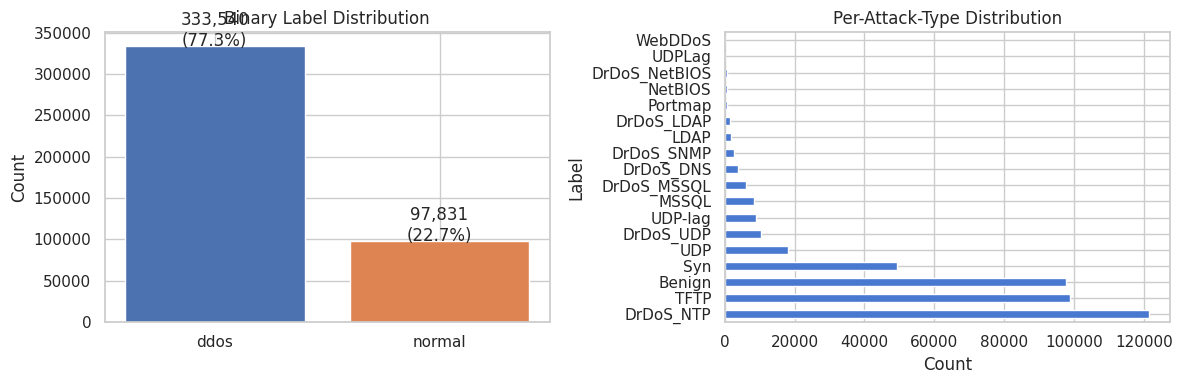

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary
counts = df['Label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')
axes[0].set_title('Binary Label Distribution')
axes[0].set_ylabel('Count')

# Multi-class (raw label col from original files)
# reload to get original labels
df_raw_labels = pd.concat([pd.read_parquet(p)['Label'].astype(str) for p in sorted(KAGGLE_DIR.glob('*.parquet'))], ignore_index=True)
orig_counts = df_raw_labels.value_counts()
orig_counts.plot(kind='barh', ax=axes[1])
axes[1].set_title('Per-Attack-Type Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

## Feature Statistics

In [8]:
import yaml
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)
features = cfg['features']

# Only keep features that exist in the dataframe
features = [f for f in features if f in df.columns]
print(f'Using {len(features)} features')
df[features].describe().T

Using 16 features


,count,mean,std,min,25%,50%,75%,max
Flow Duration,431371.0,8.404856e+06,2.126596e+07,1.00000,787.000000,44804.000000,3.002508e+06,1.199987e+08
Total Fwd Packets,431371.0,2.413912e+01,1.958889e+02,1.00000,4.000000,4.000000,1.600000e+01,8.666600e+04
Total Backward Packets,431371.0,2.472021e+00,5.637021e+01,0.00000,0.000000,0.000000,2.000000e+00,3.170000e+04
Fwd Packets Length Total,431371.0,9.416956e+03,3.454228e+04,0.00000,78.000000,2064.000000,5.160000e+03,1.526642e+07
Bwd Packets Length Total,431371.0,1.632896e+03,1.063907e+05,0.00000,0.000000,0.000000,0.000000e+00,5.842950e+07
Fwd Packet Length Mean,431371.0,3.249153e+02,2.683636e+02,0.00000,32.000000,428.000000,5.160000e+02,3.015291e+03
Bwd Packet Length Mean,431371.0,2.594426e+01,1.254355e+02,0.00000,0.000000,0.000000,0.000000e+00,5.011060e+03
Flow Bytes/s,431371.0,7.373761e+07,3.323484e+08,0.00000,656.038149,9818.076812,8.994595e+06,2.944000e+09
Flow Packets/s,431371.0,1.266888e+05,4.142850e+05,0.03392,1.332938,128.753983,3.346043e+04,4.000000e+06
Fwd IAT Mean,431371.0,9.762454e+05,1.994133e+06,0.00000,6.000000,269.684204,1.000336e+06,5.119989e+07


In [9]:
# Null/inf check
import numpy as np
numeric = df[features].select_dtypes(include=[np.number])
print('Null values:', numeric.isnull().sum().sum())
print('Inf values:', np.isinf(numeric.values).sum())

Null values: 0
Inf values: 0


## Feature Distributions (normal vs ddos)

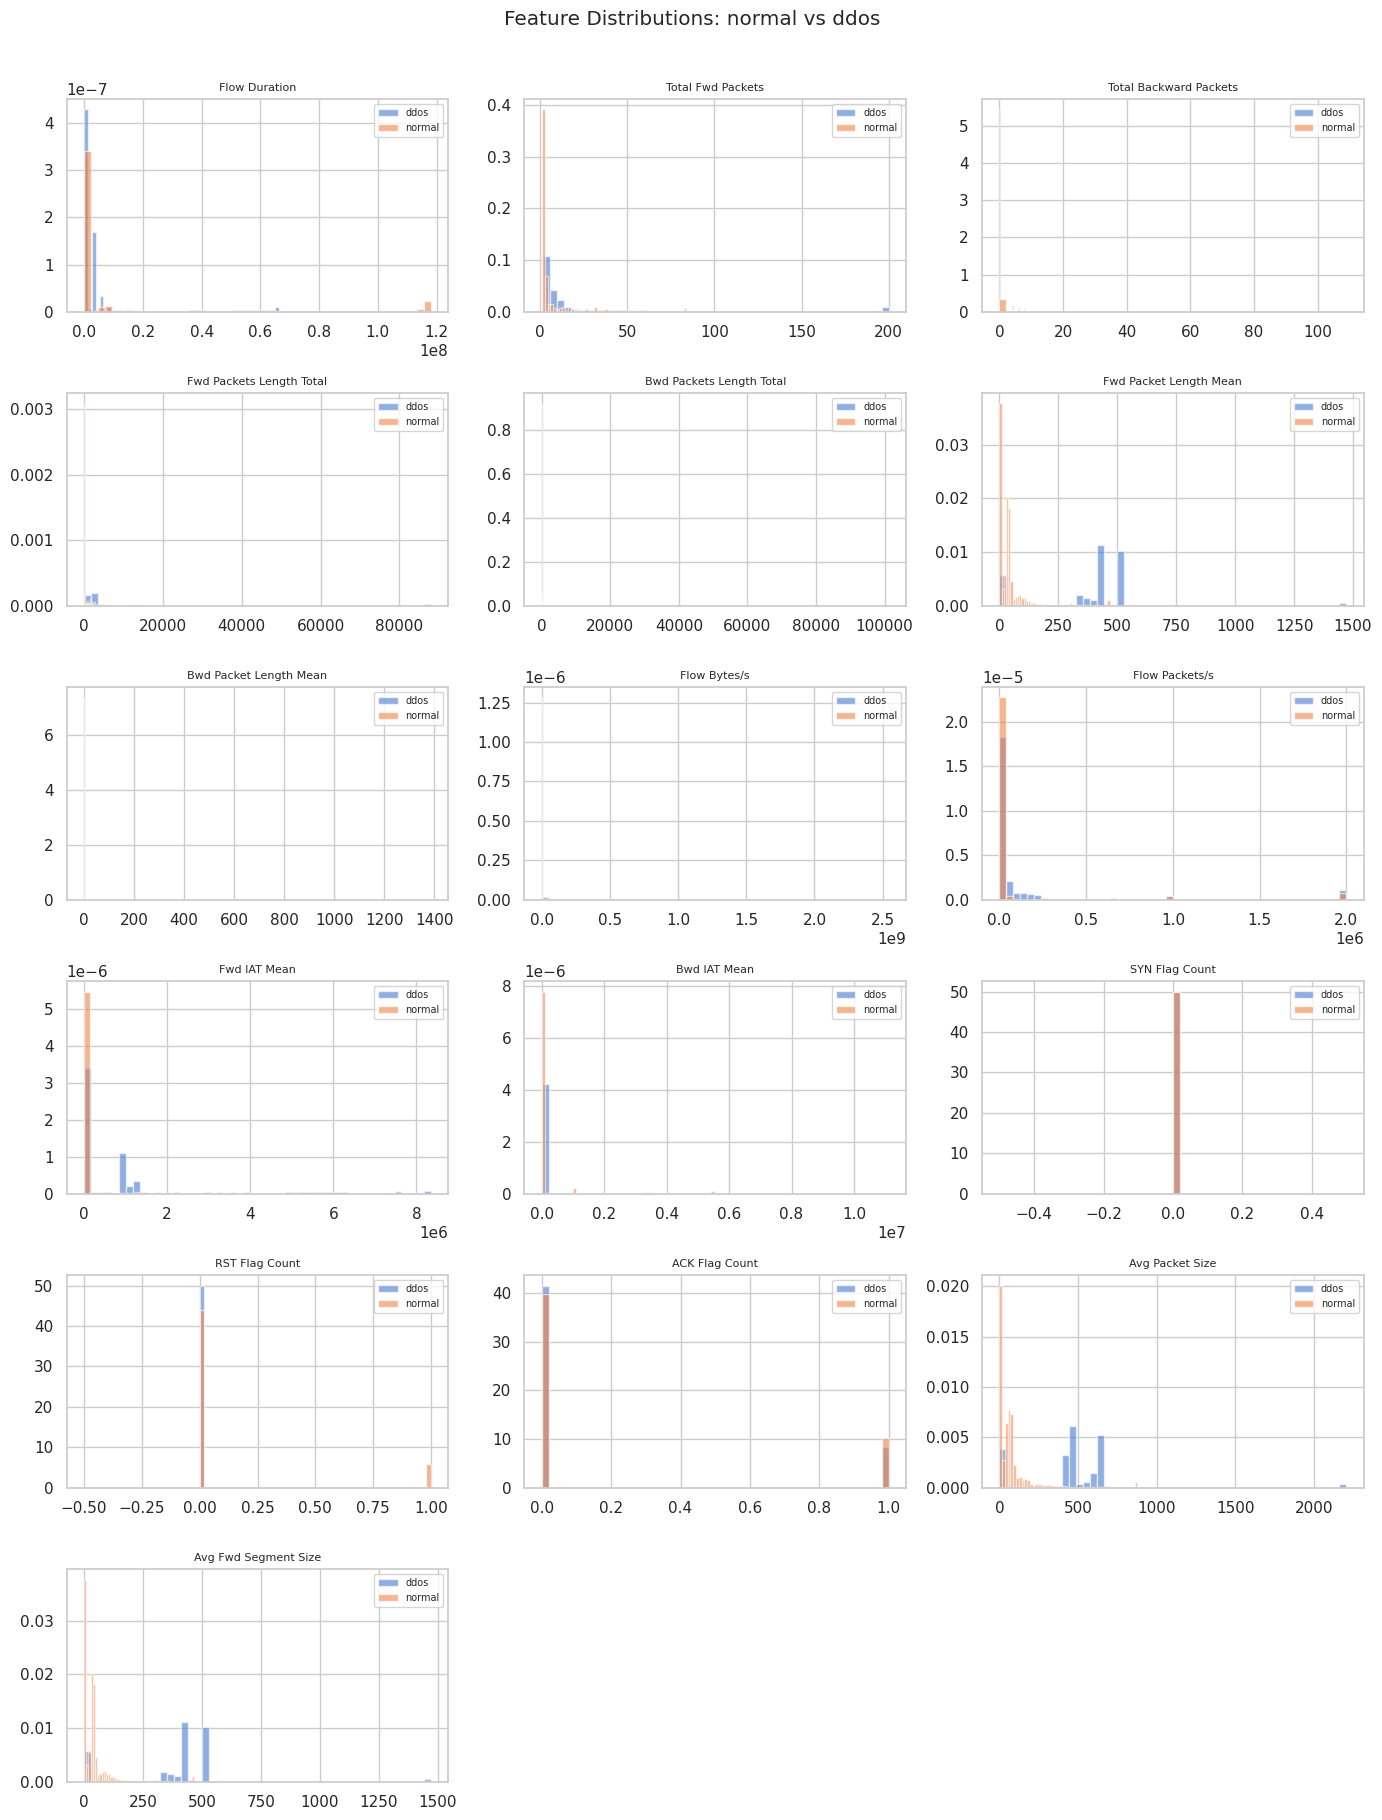

In [10]:
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, grp in df.groupby('Label'):
        data = grp[feat].astype(float)
        # clip extreme outliers for readability
        lo, hi = data.quantile(0.01), data.quantile(0.99)
        data = data.clip(lo, hi)
        axes[i].hist(data, bins=50, alpha=0.6, label=label, density=True)
    axes[i].set_title(feat, fontsize=8)
    axes[i].legend(fontsize=7)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: normal vs ddos', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap

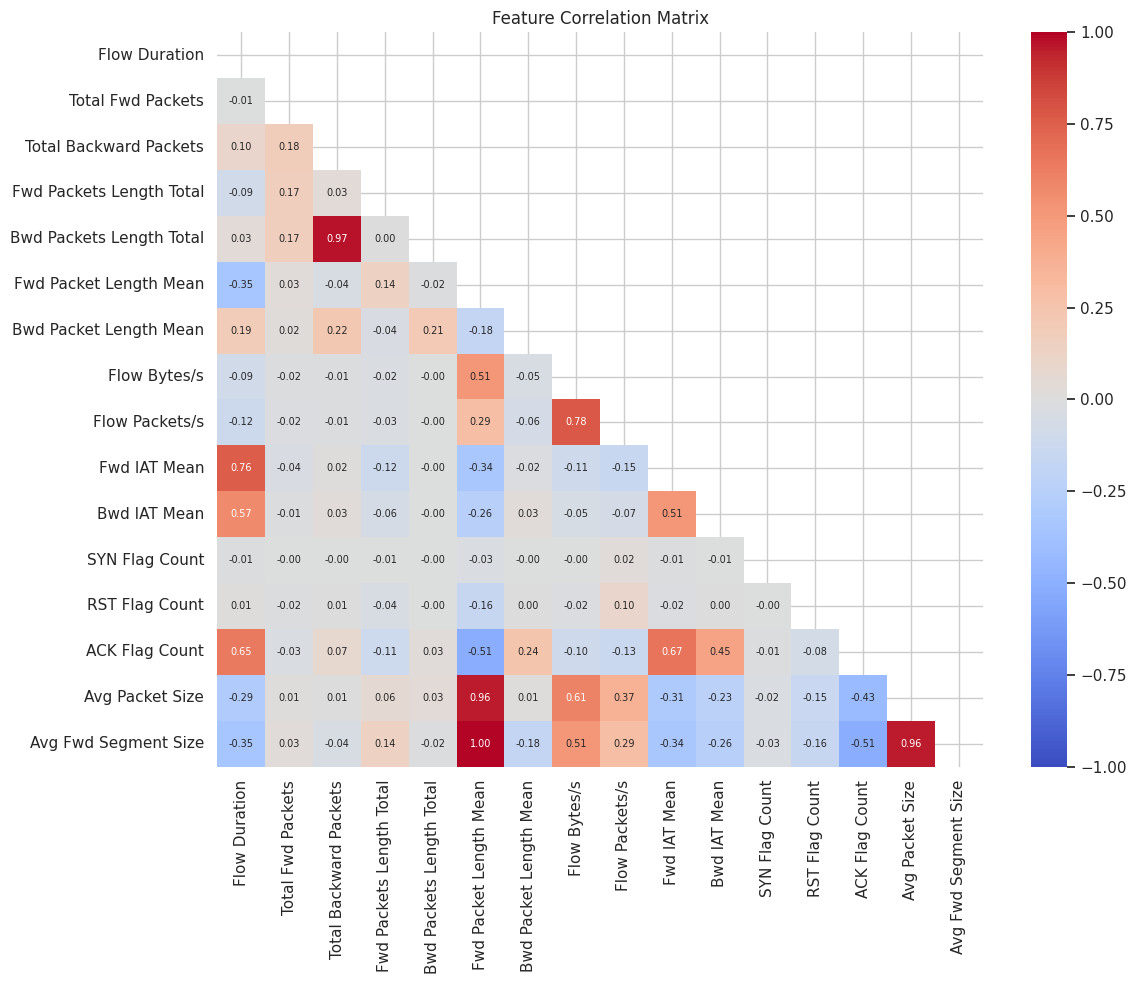

Highly correlated pairs (|r| > 0.95):
  Total Backward Packets <-> Bwd Packets Length Total: 0.974
  Fwd Packet Length Mean <-> Avg Packet Size: 0.958
  Fwd Packet Length Mean <-> Avg Fwd Segment Size: 1.0
  Avg Packet Size <-> Avg Fwd Segment Size: 0.958


In [11]:
corr = df[features].astype(float).corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/figures/correlation_heatmap.png', dpi=150)
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.index[i], corr.columns[j], round(corr.iloc[i,j], 3)))
if high_corr:
    print('Highly correlated pairs (|r| > 0.95):')
    for a, b, r in high_corr:
        print(f'  {a} <-> {b}: {r}')
else:
    print('No pairs with |r| > 0.95')